### FILTRO 5

#### 1.  Imports e carregamento dos dados

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import os

data_path = os.path.join('..', 'data', 'filtro05_processado.csv')

df = pd.read_csv(data_path)

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head(2)

Dataset carregado: 7 linhas x 55 colunas


,Title,Protocolo,Tipo (Síncrona/Assíncrona),Transmissão de dados em tempo real,Padrão de comunicação,Parâmetro Monitorado,Contexto de Monitoramento,Características do Monitoramento,Local de Monitoramento,Linguagem de Programação,...,Latência fim a fim,RTT (Round Trip Time),Packet Delay Budget (PDB),Tempo de Resposta,Jitter,Throughput,Taxa de perda de pacotes,Disponibilidade da Rede,Frequência de Operação,Largura de banda do link
0,Towards a european health data slice,"Udp, http",Não especificado,Sim,5g sa,"Eletrocardiograma (ecg), saturação de oxigênio...",Remoto,"Tempo real, contínuo","Hospital, residência, instalações de cuidados ...",Python,...,Não especificado,NaN,NaN,NaN,NaN,160 mbps (dl);80 mbps (ul),NaN,≈100%,3.5 ghz,70 mhz
1,Ai-driven data analytics and intent-based netw...,NaN,Não especificado,Sim,B5g,NaN,NaN,Automático,NaN,"Python, java",...,Não especificado,NaN,NaN,NaN,5ms (iot);7.1ms (embb),200 mbps (iot);136 mbps (embb);72 mbps (urllc),NaN,NaN,Não especificado,NaN


#### 2.  Padronização global de estilo

In [42]:
PALETTE = [
    '#3A6B8A',
    '#C8773A',
    '#4A7C59',
    '#5C4E8A',
    '#7A9E9F',
]

HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    'custom_heatmap',
    [ "#6CB3DC", '#5C4E8A'],
    N=256
)

FIG_SIZE = (12, 6)

plt.rcParams.update({
    'font.family'                : 'serif',
    'font.serif'                 : ['Latin Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset'           : 'cm',
    'axes.formatter.use_mathtext': True,

    'font.size'       : 13,
    'axes.titlesize'  : 16,
    'axes.labelsize'  : 14,
    'xtick.labelsize' : 12,
    'ytick.labelsize' : 12,

    'axes.linewidth'    : 1.2,
    'xtick.major.width' : 1.1,
    'ytick.major.width' : 1.1,
    'xtick.major.size'  : 4,
    'ytick.major.size'  : 4,

    'axes.grid'        : False,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
})

print('✔  Estilo padronizado aplicado com sucesso.')

✔  Estilo padronizado aplicado com sucesso.


#### 3. Função auxiliar para gráfico de barras

In [43]:
def plot_bar(counts, title, xlabel, ylabel='',
             color_cycle=None, filename=None):
    """
    Parâmetros:
    -------------------------------------------------------------------------
    counts      : pd.Series  — index = categorias, values = contagens
    title       : str        — título do gráfico
    xlabel      : str        — rótulo do eixo X
    ylabel      : str        — rótulo do eixo Y (padrão 'Frequência')
    color_cycle : list       — lista de cores HEX (padrão: PALETTE global)
    filename    : str        — se informado, salva a figura em PNG
    """
    if color_cycle is None:
        color_cycle = PALETTE

    n      = len(counts)
    colors = [color_cycle[i % len(color_cycle)] for i in range(n)]

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    bars = ax.bar(counts.index, counts.values,
                  color=colors, width=0.65,
                  edgecolor='white', linewidth=0.6)

    # rótulos sobre as barras
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + 0.12,
                str(int(h)),
                ha='center', va='bottom',
                fontsize=12)

    ax.set_title(title, pad=14)
    ax.set_xlabel(xlabel, labelpad=8)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    rotation = 35 if n > 4 else 0
    ha       = 'right' if n > 4 else 'center'
    ax.set_xticks(range(n))
    ax.set_xticklabels(counts.index, rotation=rotation, ha=ha)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

print('✔  Função plot_bar() definida.')

✔  Função plot_bar() definida.


### Arquitetura e Configuração da Rede

#### 4. Figura 1: Padrão de Comunicação

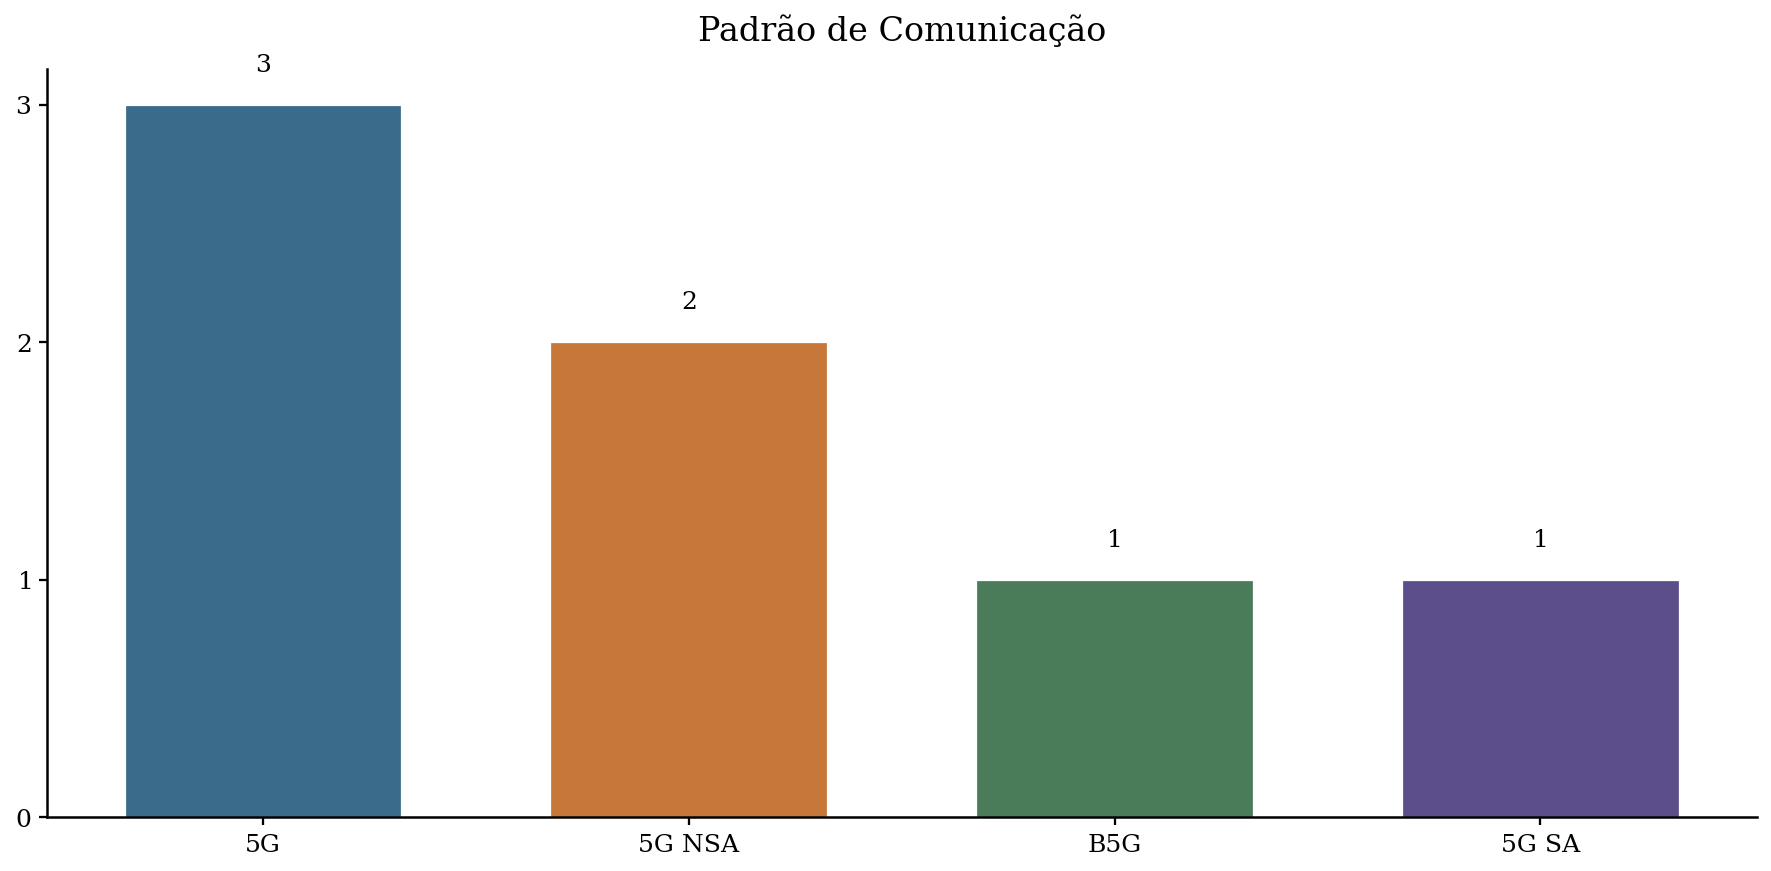

In [44]:

counts_padrao = (
    df['Padrão de comunicação']
    .dropna()
    .str.upper()
    .value_counts()
)

plot_bar(
    counts_padrao,
    title='Padrão de Comunicação',
    xlabel='',
    ylabel='',
)

#### 5. Figura 2: Função do Nó

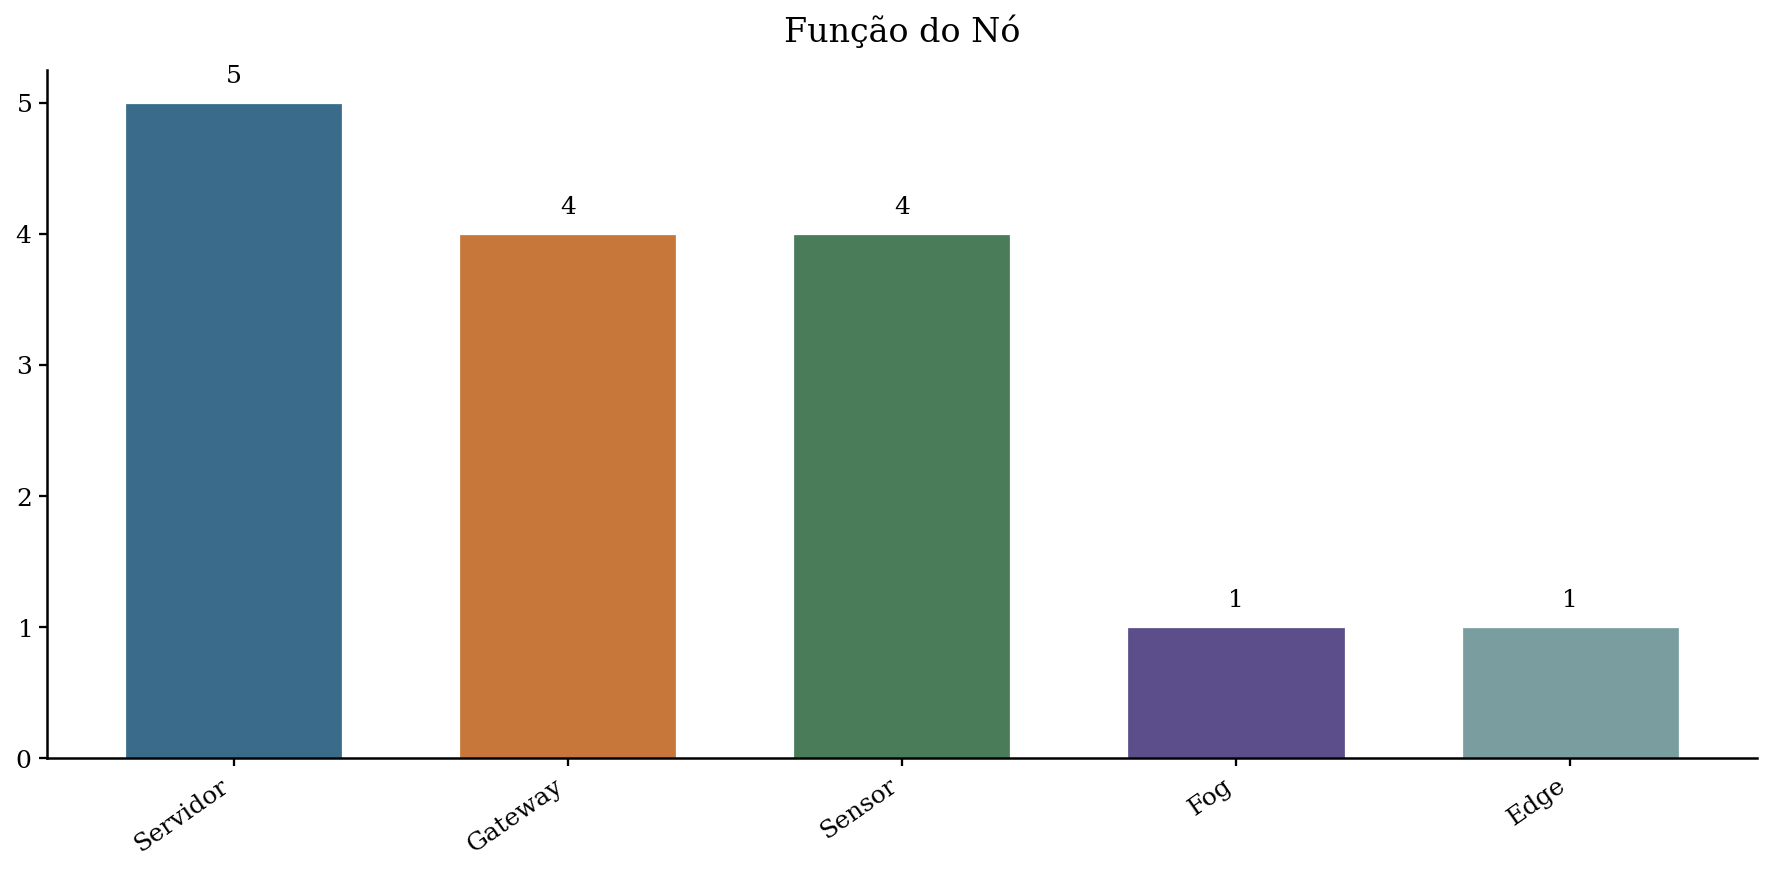

In [45]:

counts_funcao_no = (
    df['Função do Nó']
    .dropna()
    .astype(str)
    .str.split(';')
    .explode()
    .str.strip()
    .str.title()
    .replace({'Não Especificado': None})
    .dropna()
    .value_counts()
)

plot_bar(
    counts_funcao_no,
    title='Função do Nó',
    xlabel='',
    ylabel='',
)

#### 6. Figura 3: Tipo de Enlace

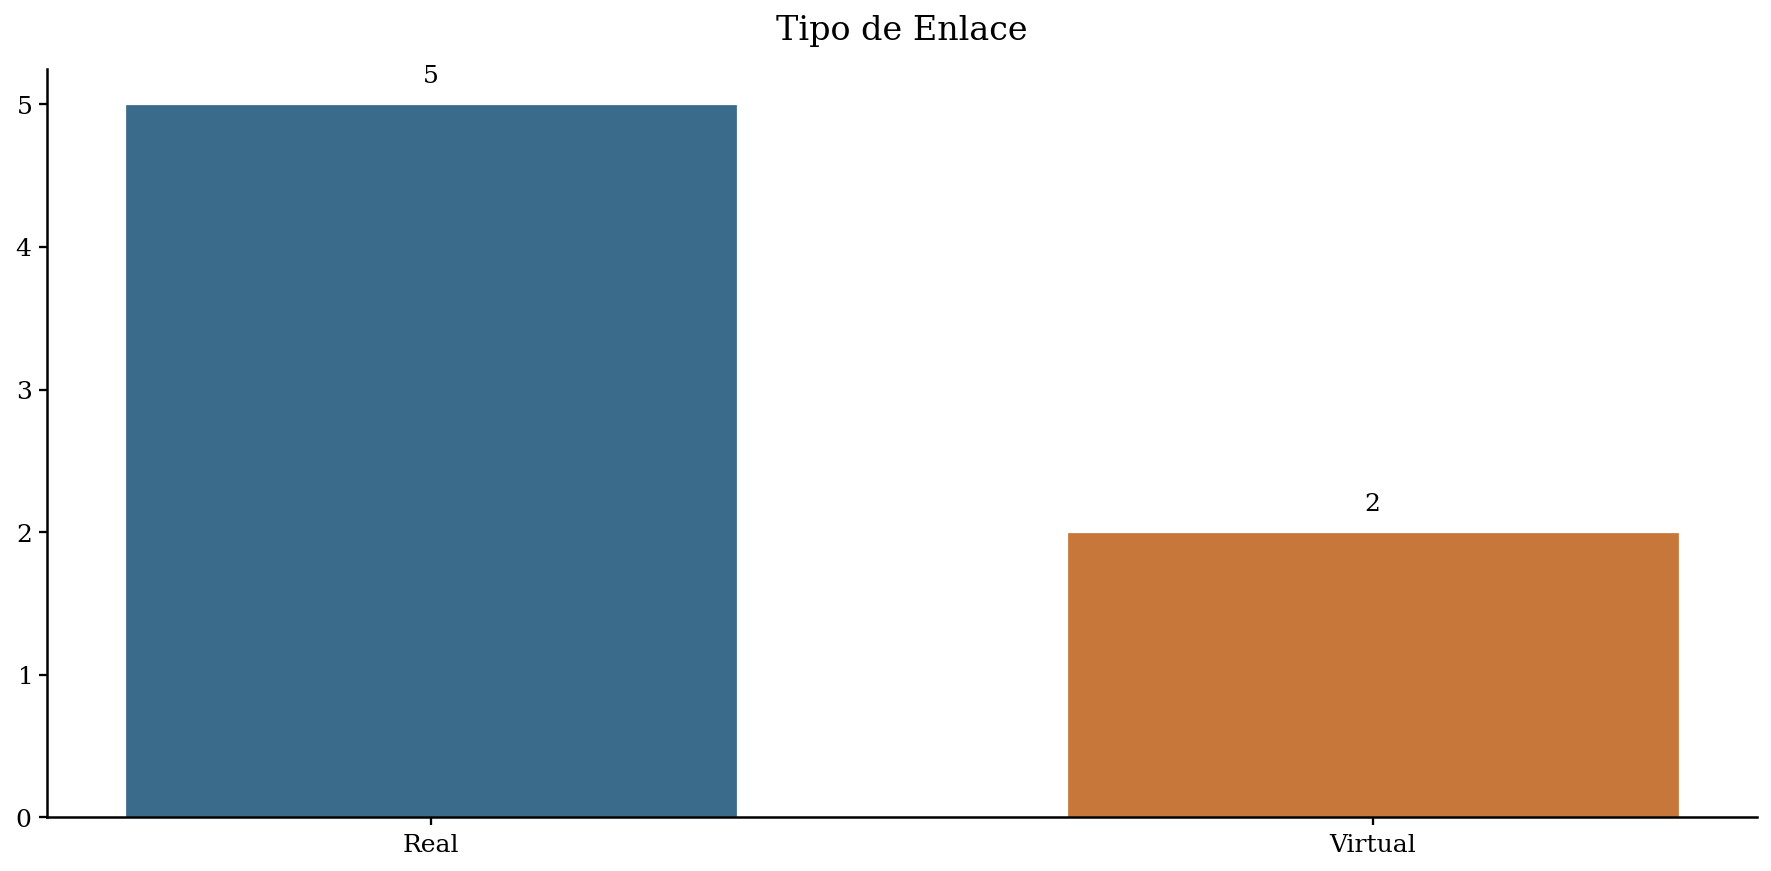

In [46]:
counts_enlace = (
    df['Tipo de Enlace']
    .dropna()
    .str.title()
    .value_counts()
)

plot_bar(
    counts_enlace,
    title='Tipo de Enlace',
    xlabel='',
    ylabel='',
)

### Especificação do Monitoramento de Pacientes

#### 7. Figura 4: Parâmetros Monitorados

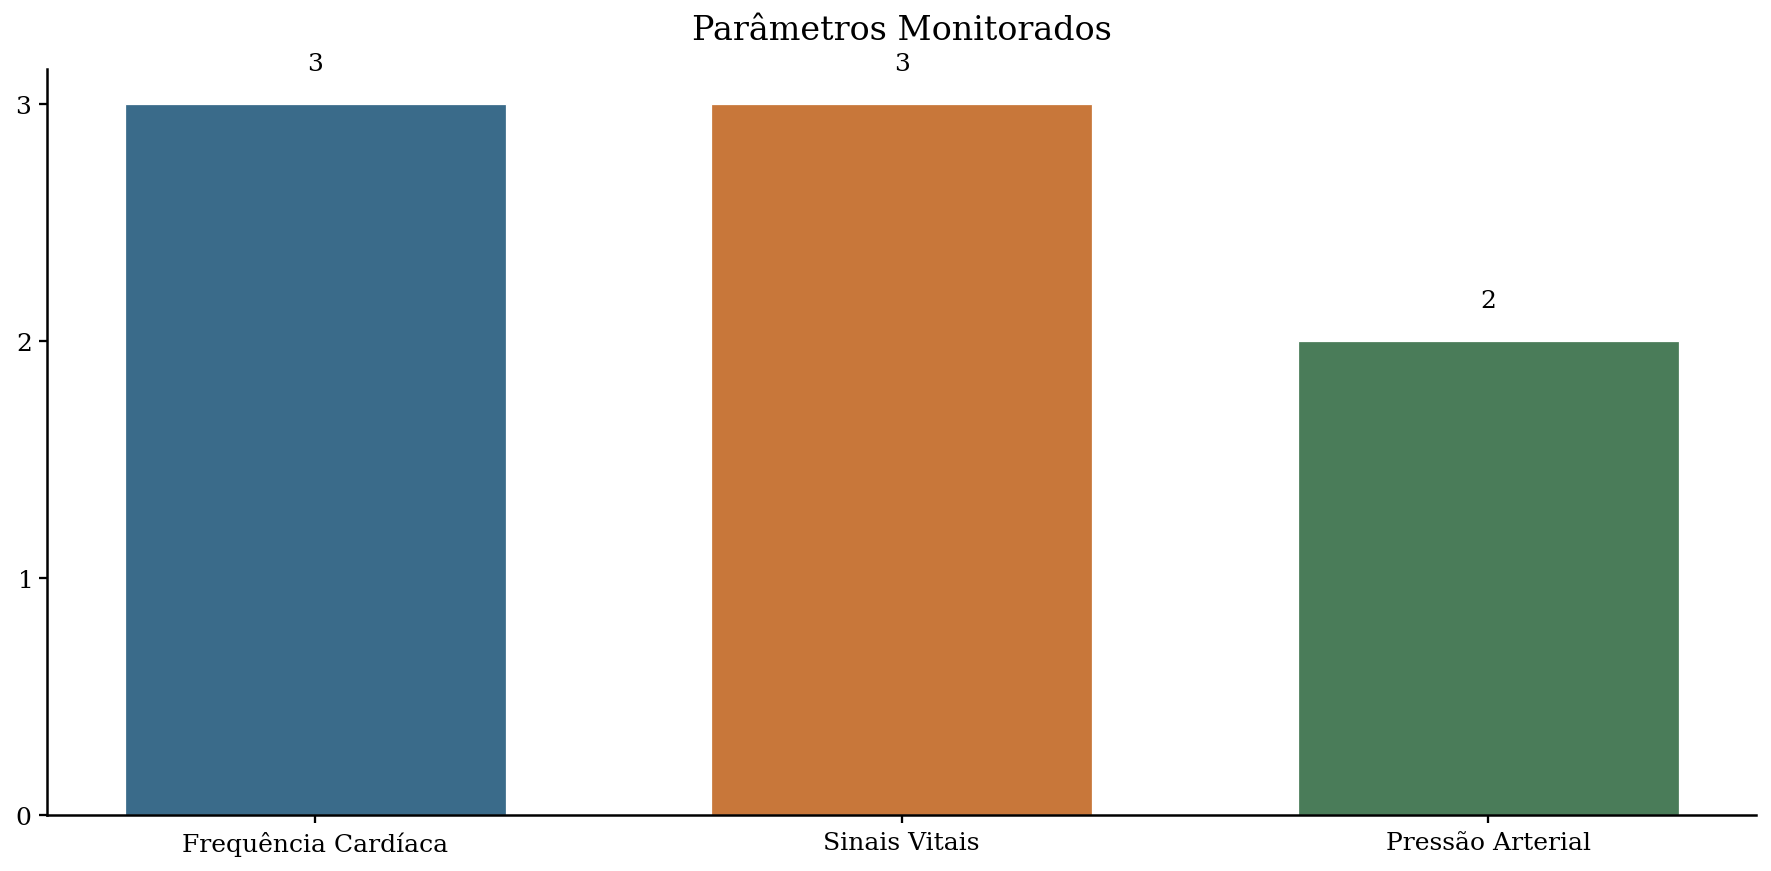

In [47]:
counts_parametro = (
    df['Parâmetro Monitorado']
    .dropna()
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
    .str.title()
    .replace({'Não Especificado': None, 'Nan': None})
    .dropna()
    .value_counts()
)
counts_parametro = counts_parametro[counts_parametro >= 2]

plot_bar(
    counts_parametro,
    title='Parâmetros Monitorados',
    xlabel='',
    ylabel='',
)

#### 8. Figura 5: Características do Monitoramento

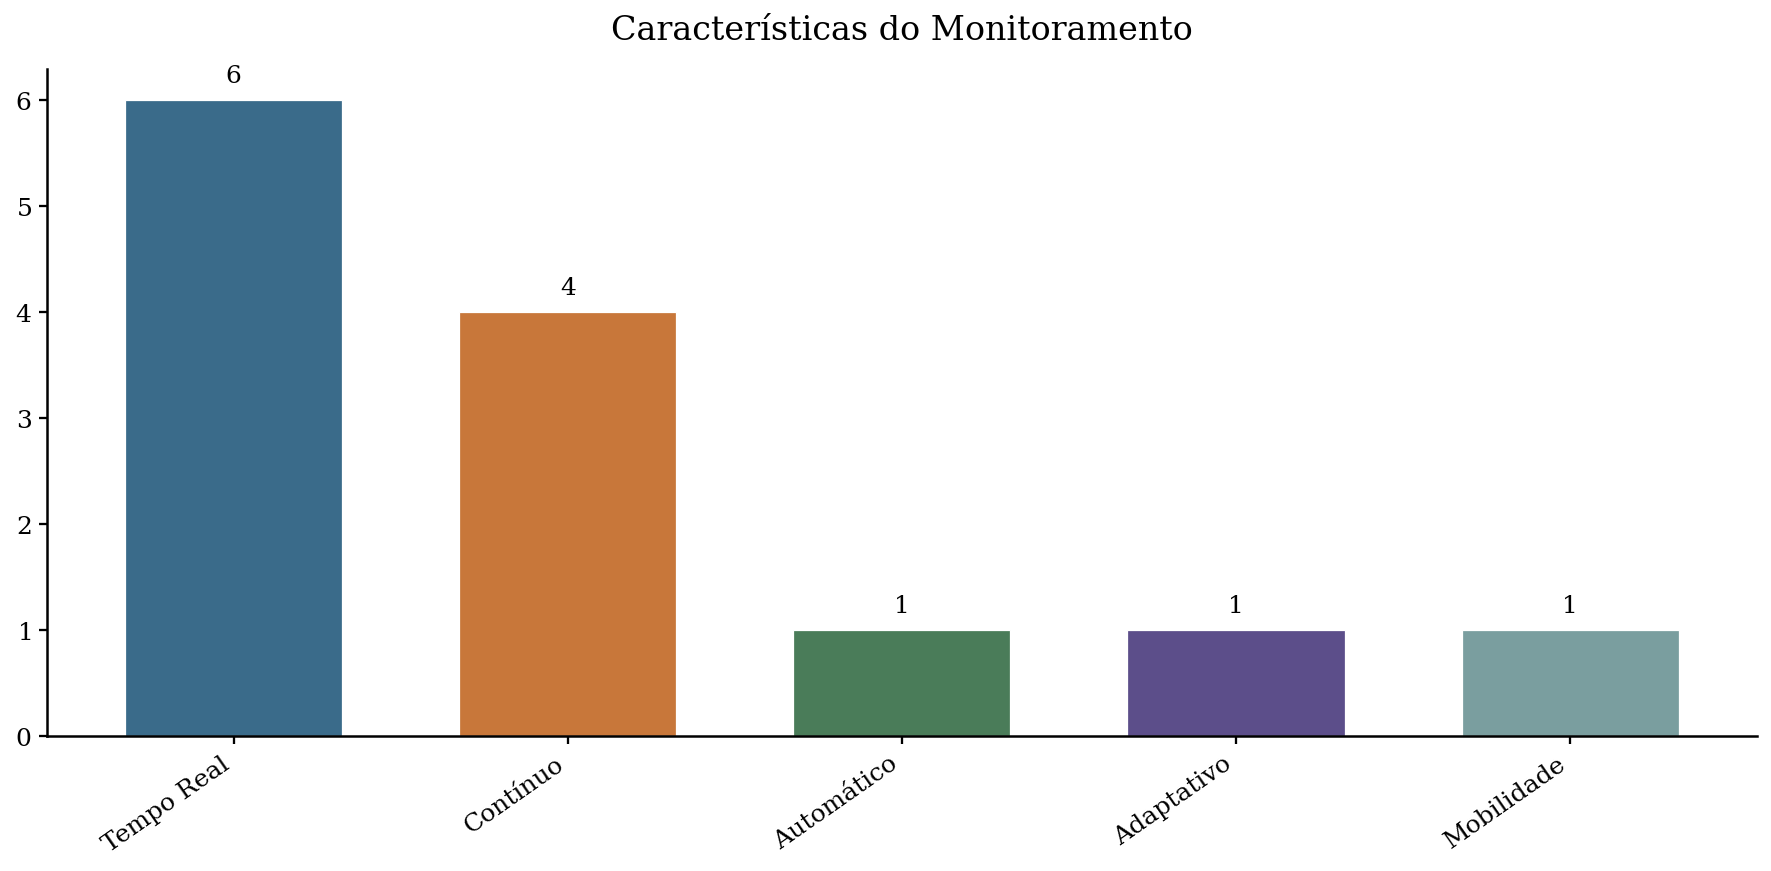

In [48]:
counts_carac = (
    df['Características do Monitoramento']
    .dropna()
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
    .str.title()
    .replace({'Nan': None})
    .dropna()
    .value_counts()
)

plot_bar(
    counts_carac,
    title='Características do Monitoramento',
    xlabel='',
    ylabel='',
)

#### 9. Figura 6: Local de Monitoramento

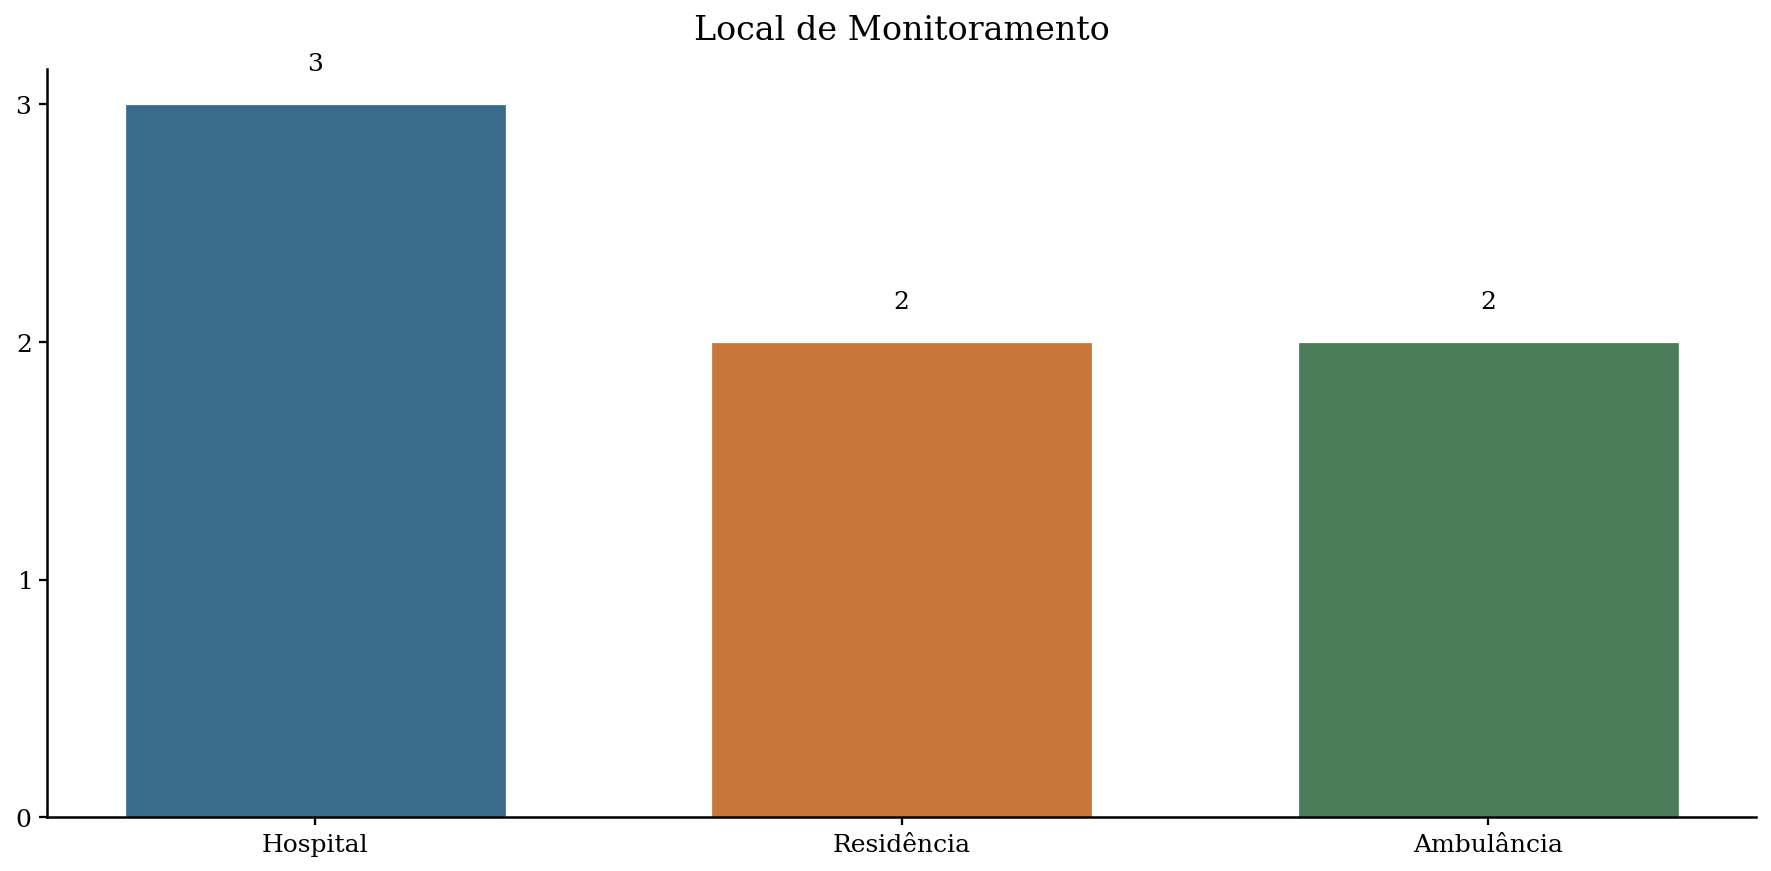

In [49]:
counts_local = (
    df['Local de Monitoramento']
    .dropna()
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
    .str.title()
    .replace({'Não Especificado': None, 'Nan': None})
    .dropna()
    .value_counts()
)
counts_local = counts_local[counts_local >= 2]

plot_bar(
    counts_local,
    title='Local de Monitoramento',
    xlabel='',
    ylabel='',
)

### Infraestrutura do Sistema

#### 10. Figura 7: Linguagem de Programação

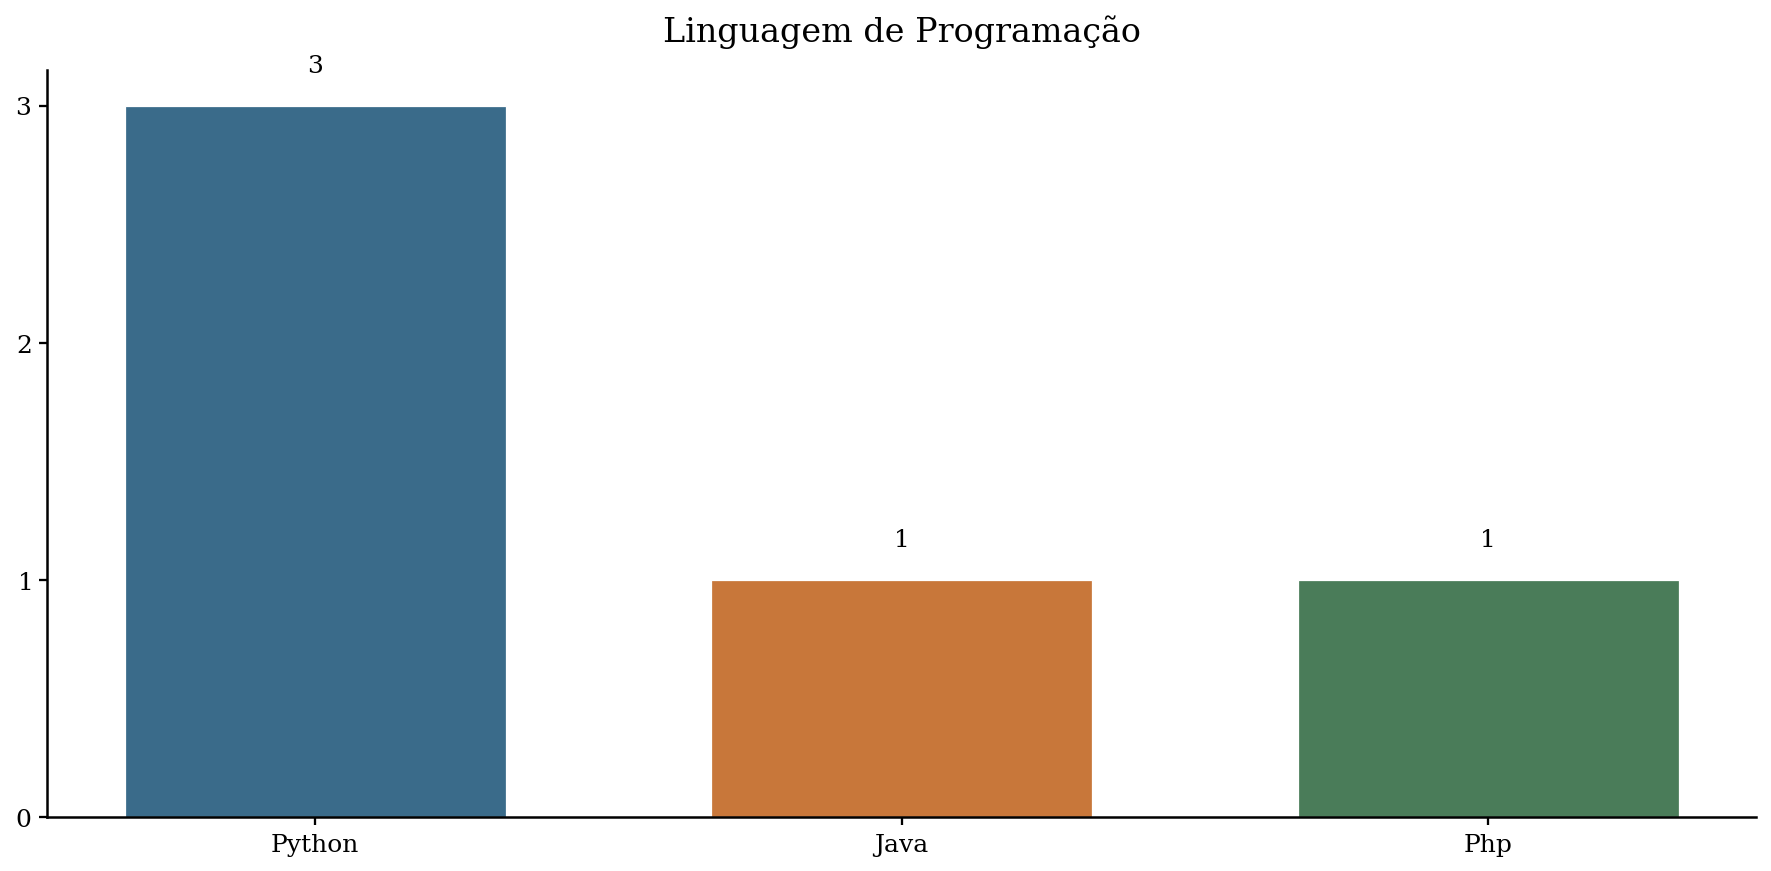

In [ ]:
counts_linguagem = (
    df['Linguagem de Programação']
    .dropna()
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
    .str.title()
    .replace({'Nan': None})
    .dropna()
    .value_counts()
)

plot_bar(
    counts_linguagem,
    title='Linguagem de Programação',
    xlabel='',
    ylabel='',
)